# MSE555 Assignment 3 — Q1: Chatbot Approach (ChatGPT 5.4 Thinking)

**Workflow:** Instead of calling an LLM API programmatically, this notebook uses a manual chatbot approach:
1. Upload the JSON data file to ChatGPT 5.4 Thinking
2. Copy-paste the scoring prompt from this notebook
3. Receive structured CSV output from the chatbot
4. Paste the CSV back into this notebook for evaluation

**Structure:**
- **Q1(a)** — Design, test, and evaluate two prompts (V1 baseline + V2 final) on 40 labeled clients
- **Q1(b)** — Run the final V2 prompt on 80 unlabeled clients and save predictions

In [18]:
import json
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, cohen_kappa_score, mean_absolute_error, accuracy_score
from scipy.stats import spearmanr

In [19]:
with open('../data/labeled_notes.json') as f:
    labeled_data = json.load(f)
with open('../data/unlabeled_notes.json') as f:
    unlabeled_data = json.load(f)

print(f"Labeled:   {len(labeled_data)} clients, {len(labeled_data[0]['notes'])} notes each, {len(labeled_data[0]['scored_progress'])} scores each")
print(f"Unlabeled: {len(unlabeled_data)} clients, {len(unlabeled_data[0]['notes'])} notes each")
print(f"Total labeled scores: {sum(len(c['scored_progress']) for c in labeled_data)}")

Labeled:   40 clients, 12 notes each, 11 scores each
Unlabeled: 80 clients, 12 notes each
Total labeled scores: 440


## Exploratory Data Analysis

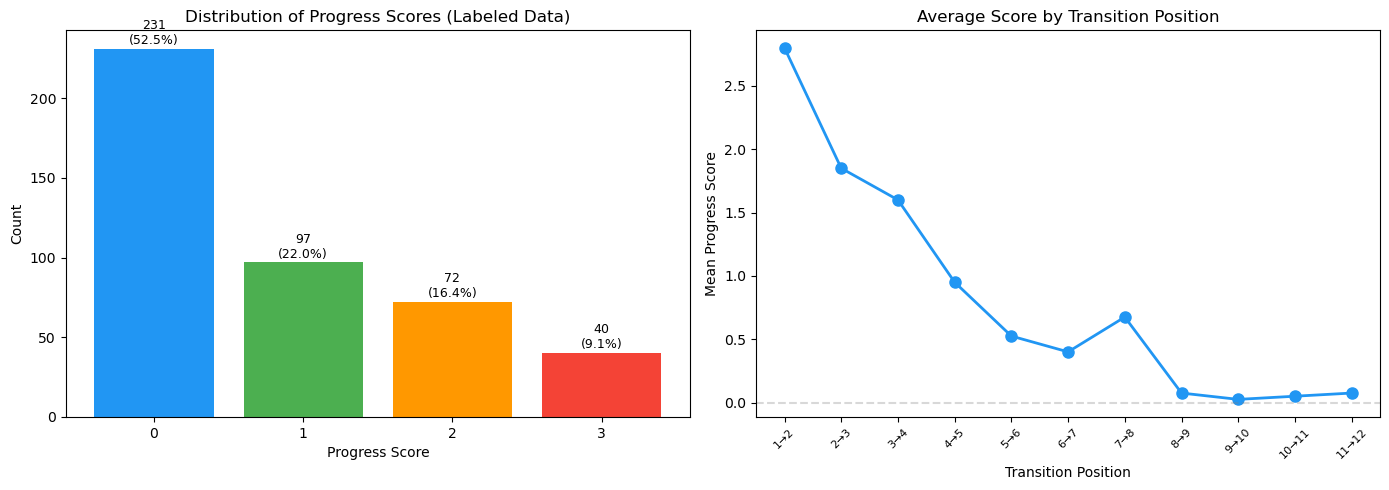

Score distribution: {0: 231, 1: 97, 2: 72, 3: 40}
Class imbalance: 52.5% are score 0
Score 3 at transition 1: 32/40


In [20]:
rows = []
for client in labeled_data:
    for i, score in enumerate(client['scored_progress']):
        rows.append({'client_id': client['client_id'], 'transition': i + 1, 'score': score})
scores_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: score distribution
counts = scores_df['score'].value_counts().sort_index()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
bars = axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_xlabel('Progress Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Progress Scores (Labeled Data)')
axes[0].set_xticks([0, 1, 2, 3])
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 3,
                 f'{v}\n({v/len(scores_df)*100:.1f}%)', ha='center', fontsize=9)

# Right: mean score by transition position
mean_by_pos = scores_df.groupby('transition')['score'].mean()
axes[1].plot(mean_by_pos.index, mean_by_pos.values, 'o-', color='#2196F3', linewidth=2, markersize=8)
axes[1].set_xlabel('Transition Position')
axes[1].set_ylabel('Mean Progress Score')
axes[1].set_title('Average Score by Transition Position')
axes[1].set_xticks(range(1, 12))
axes[1].set_xticklabels([f'{i}→{i+1}' for i in range(1, 12)], rotation=45, fontsize=8)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Score distribution: { {int(k): int(v) for k,v in counts.items()} }")
print(f"Class imbalance: {counts[0]/len(scores_df)*100:.1f}% are score 0")
print(f"Score 3 at transition 1: {scores_df[(scores_df.transition==1)&(scores_df.score==3)].shape[0]}/{scores_df[scores_df.transition==1].shape[0]}")

### Create Test Set (Labels Removed)

Strip the expert `scored_progress` labels from the 40 labeled clients and save as a clean test file for model evaluation.

In [21]:
test_data = [{'client_id': c['client_id'], 'notes': c['notes']} for c in labeled_data]

with open('../data/test_notes.json', 'w') as f:
    json.dump(test_data, f, indent=2)

print(f"Saved {len(test_data)} clients to data/test_notes.json (no labels)")

Saved 40 clients to data/test_notes.json (no labels)


## Q1(a): Prompt Design, Testing & Evaluation (Labeled Data)

This section develops and evaluates two prompts on the 40 labeled clients:
- **V1 (Baseline):** Minimal instructions — task description, 0-3 scale, output format only
- **V2 (Final):** Enhanced with persona, clinical framework, scale definitions, calibration, few-shot examples

### LLM Choice

**Model:** ChatGPT 5.4 Thinking (OpenAI)

**Approach:** Manual chatbot interaction — upload the full JSON data file, paste the scoring prompt, and receive CSV output.
- **Batch processing:** All clients are scored in a single conversation turn
- **Larger context:** ChatGPT 5.4 Thinking can ingest the full JSON file via file upload
- **Reasoning mode:** The "Thinking" model performs extended chain-of-thought before responding

### V1 Prompt Strategy (Baseline)

Minimal instructions — just the task description, the 0-3 scale, and the output format. No persona, no calibration, no framework, no examples.

### V1 Prompt (Baseline) — Labeled Data

**Instructions:** Upload `data/test_notes.json` to ChatGPT 5.4 Thinking, then copy-paste the prompt below.

```
You are evaluating speech-language pathology clients' progress between consecutive therapy sessions.

I have uploaded a JSON file (test_notes.json) containing 40 clients. Each client has 12 consecutive session notes.

For each client, score the progress for each of the 11 consecutive transitions (session 1→2, 2→3, 3→4, 4→5, 5→6, 6→7, 7→8, 8→9, 9→10, 10→11, 11→12):
- 0: No notable change
- 1: Minimal progress
- 2: Moderate progress
- 3: Major progress

There are 12 sessions and exactly 11 transitions between them.

Return ONLY a CSV table with this exact format:

client_id,t1_2,t2_3,t3_4,t4_5,t5_6,t6_7,t7_8,t8_9,t9_10,t10_11,t11_12

Each row: client_id followed by 11 integer scores (each 0, 1, 2, or 3).
Exactly 40 rows (one per client), sorted by client_id.
No explanation, no markdown formatting — ONLY the CSV.
```

### Evaluation Approach & Justification

We use the same 5 metrics as the programmatic approach:

| Metric | Why |
|--------|-----|
| **Quadratic Weighted Kappa (QWK)** | Primary metric — ordinal inter-rater agreement, chance-corrected, penalizes distant disagreements quadratically |
| **Mean Absolute Error (MAE)** | Average magnitude of errors on the 0-3 scale |
| **Exact Accuracy** | Fraction of predictions exactly matching expert score |
| **Within-1 Accuracy** | Fraction within ±1 of true score — clinically acceptable error tolerance |
| **Spearman Correlation** | Rank-order agreement with p-value |

Note: With 52.5% of scores being 0, a trivial all-zeros classifier achieves ~52.5% accuracy — so accuracy alone is insufficient.

In [22]:
def evaluate(y_true, y_pred, label=""):
    """Compute and print all evaluation metrics."""
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    mae = mean_absolute_error(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    within1 = np.mean(np.abs(np.array(y_true) - np.array(y_pred)) <= 1)
    spearman, p_val = spearmanr(y_true, y_pred)

    if label:
        print(f"\n{'='*50}")
        print(f"  {label}")
        print(f"{'='*50}")
    print(f"  Quadratic Weighted Kappa:  {qwk:.3f}")
    print(f"  MAE:                       {mae:.3f}")
    print(f"  Exact Accuracy:            {acc:.3f}")
    print(f"  Within-1 Accuracy:         {within1:.3f}")
    print(f"  Spearman Correlation:      {spearman:.3f} (p={p_val:.2e})")

    return {'qwk': qwk, 'mae': mae, 'accuracy': acc, 'within1': within1, 'spearman': spearman}

In [23]:
# Paste the ChatGPT CSV output (from V1 prompt) between the triple quotes below

# raw_output_v1 = """
# <PASTE V1 CSV HERE>
# """

raw_output_v1 = """
client_id,t1_2,t2_3,t3_4,t4_5,t5_6,t6_7,t7_8,t8_9,t9_10,t10_11,t11_12
C_006,1,1,2,0,1,1,1,1,1,1,3
C_010,0,1,1,1,0,1,1,2,2,2,1
C_012,1,0,2,0,1,2,2,0,0,0,0
C_014,0,1,1,1,0,0,1,0,0,1,2
C_017,0,1,1,1,0,1,1,1,0,0,1
C_024,0,1,0,1,0,1,2,0,0,2,1
C_027,1,0,1,0,1,1,0,0,0,0,0
C_029,0,1,0,2,0,1,1,0,0,1,0
C_032,0,1,0,0,1,2,2,2,2,1,0
C_034,1,1,3,2,0,2,1,2,1,0,0
C_035,0,1,0,2,0,2,0,0,0,0,0
C_036,1,1,2,1,0,1,2,3,0,0,0
C_045,0,0,3,0,0,0,1,0,2,0,0
C_046,1,0,2,0,2,2,0,2,0,0,2
C_047,1,0,2,0,0,0,1,0,0,1,2
C_056,0,1,1,1,2,1,0,1,0,0,3
C_061,0,0,0,0,0,0,1,0,0,1,0
C_063,0,1,2,0,0,0,1,0,2,0,0
C_064,0,1,3,0,0,2,0,0,0,1,0
C_068,0,1,2,0,0,2,2,0,0,1,2
C_073,0,1,0,1,2,1,1,1,0,0,0
C_075,0,0,1,1,0,0,0,0,0,0,0
C_085,0,1,0,2,2,0,0,1,1,0,1
C_086,1,1,0,2,0,0,0,0,0,0,0
C_089,1,2,0,1,0,2,0,0,0,0,0
C_090,1,0,1,2,0,0,0,2,0,2,3
C_091,1,2,2,0,3,0,2,0,0,0,3
C_092,0,1,2,0,0,0,0,0,3,1,2
C_101,1,0,3,0,1,0,0,0,0,0,0
C_103,0,0,1,1,1,2,2,0,0,0,1
C_104,1,0,0,2,0,2,2,1,1,0,0
C_105,1,2,1,0,0,0,0,1,0,1,0
C_108,0,0,0,1,3,1,3,0,0,0,0
C_109,1,2,0,0,0,0,0,0,0,0,2
C_110,1,2,1,2,1,0,0,1,0,0,0
C_112,0,1,0,1,0,2,2,1,0,1,0
C_113,0,2,3,2,0,0,0,0,0,0,2
C_114,3,0,0,0,0,0,0,0,0,0,0
C_116,0,0,0,3,2,1,0,0,0,0,1
C_120,1,0,0,0,0,1,2,0,0,2,2
"""

# --- Robust CSV parser ---
text = raw_output_v1.strip()
# Strip markdown code fences if present
if text.startswith("```"):
    lines = text.split("\n")
    lines = [l for l in lines if not l.strip().startswith("```")]
    text = "\n".join(lines).strip()

df_v1_pred = pd.read_csv(io.StringIO(text))

# Validate
assert len(df_v1_pred) == 40, f"Expected 40 rows, got {len(df_v1_pred)}"
score_cols = [c for c in df_v1_pred.columns if c.startswith('t')]
assert len(score_cols) == 11, f"Expected 11 score columns, got {len(score_cols)}"

# Validate score values
all_vals = df_v1_pred[score_cols].values.flatten()
assert all(v in [0, 1, 2, 3] for v in all_vals), f"Invalid score values found: {set(all_vals) - {0,1,2,3}}"

# Build prediction arrays aligned with ground truth
labeled_map = {c['client_id']: c['scored_progress'] for c in labeled_data}
y_true, y_pred = [], []
for _, row in df_v1_pred.iterrows():
    cid = row['client_id']
    assert cid in labeled_map, f"Client {cid} not found in labeled data"
    y_true.extend(labeled_map[cid])
    y_pred.extend([int(row[c]) for c in score_cols])

print(f"Parsed {len(df_v1_pred)} clients, {len(y_true)} total scores")
print(f"Score value range: {min(y_pred)} to {max(y_pred)}")
print(f"Prediction distribution: { {s: y_pred.count(s) for s in range(4)} }")

Parsed 40 clients, 440 total scores
Score value range: 0 to 3
Prediction distribution: {0: 235, 1: 118, 2: 71, 3: 16}


In [24]:
v1_metrics = evaluate(y_true, y_pred, "V1 Baseline (40 labeled clients)")


  V1 Baseline (40 labeled clients)
  Quadratic Weighted Kappa:  0.182
  MAE:                       0.798
  Exact Accuracy:            0.480
  Within-1 Accuracy:         0.777
  Spearman Correlation:      0.251 (p=9.19e-08)


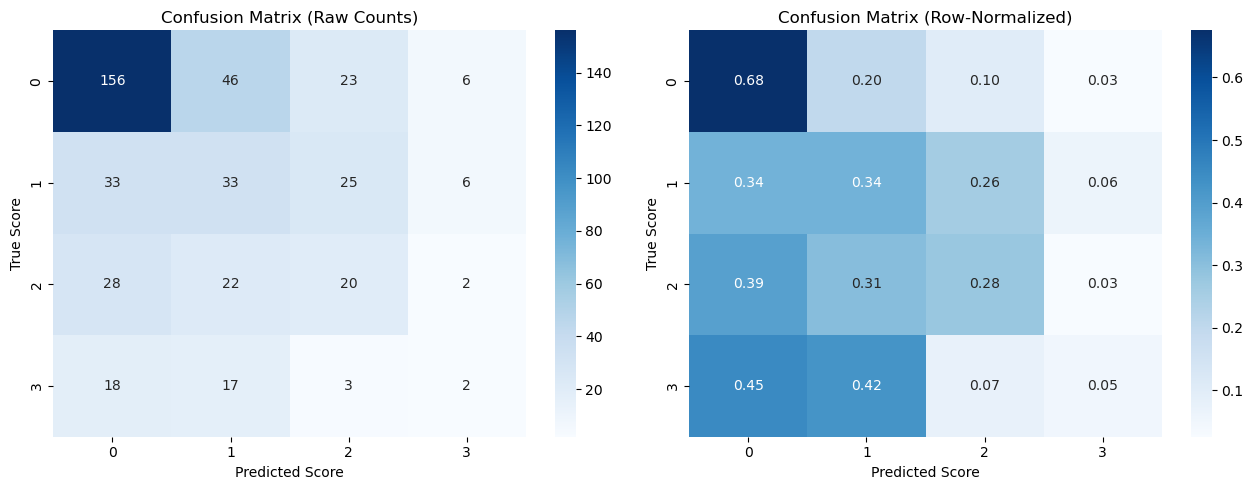


Per-class recall (row-normalized diagonal):
  Score 0: 0.68  (156/231)
  Score 1: 0.34  (33/97)
  Score 2: 0.28  (20/72)
  Score 3: 0.05  (2/40)


In [25]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3], ax=axes[0])
axes[0].set_xlabel('Predicted Score')
axes[0].set_ylabel('True Score')
axes[0].set_title('Confusion Matrix (Raw Counts)')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3], ax=axes[1])
axes[1].set_xlabel('Predicted Score')
axes[1].set_ylabel('True Score')
axes[1].set_title('Confusion Matrix (Row-Normalized)')

plt.tight_layout()
plt.show()

# Per-class summary
print("\nPer-class recall (row-normalized diagonal):")
for i in range(4):
    if cm.sum(axis=1)[i] > 0:
        print(f"  Score {i}: {cm_norm[i,i]:.2f}  ({cm[i,i]}/{cm.sum(axis=1)[i]})")

### Confusion Matrix Interpretation

*Fill in after running evaluation:*
- How well does the model distinguish score 0 (consolidation) from score 1 (minimal progress)?
- Does it capture the rare score 3 (breakthrough) at the right transitions?
- How does the per-transition curve compare to the expert pattern?

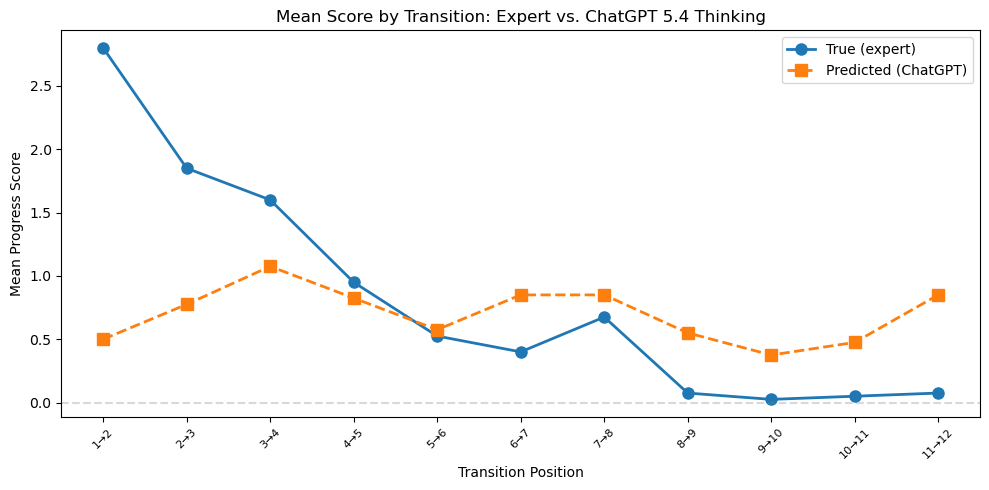

In [26]:
# Per-transition position analysis: mean predicted vs mean true
true_arr = np.array(y_true).reshape(-1, 11)
pred_arr = np.array(y_pred).reshape(-1, 11)

fig, ax = plt.subplots(figsize=(10, 5))
positions = range(1, 12)
ax.plot(positions, true_arr.mean(axis=0), 'o-', label='True (expert)', linewidth=2, markersize=8)
ax.plot(positions, pred_arr.mean(axis=0), 's--', label='Predicted (ChatGPT)', linewidth=2, markersize=8)
ax.set_xlabel('Transition Position')
ax.set_ylabel('Mean Progress Score')
ax.set_title('Mean Score by Transition: Expert vs. ChatGPT 5.4 Thinking')
ax.set_xticks(range(1, 12))
ax.set_xticklabels([f'{i}→{i+1}' for i in range(1, 12)], rotation=45, fontsize=8)
ax.legend()
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### V2 Prompt Design & Evaluation

**V2 Prompt Strategy:** Adds persona priming, detailed scale definitions, calibration guidance with per-transition means, complexity/independence framework, and 3 few-shot examples.

### V2 Prompt (Final) — Labeled Data

**Instructions:** Upload `data/test_notes.json` to ChatGPT 5.4 Thinking, then copy-paste the prompt below.

**V2 Strategies Implemented:**
- Persona / role assignment grounded in Patel's clinical judgment approach
- Case context from the Westfield case study (standardized pathway, Exhibit A framework)
- Explicit score definitions with clinical language anchors from labeled notes
- Boundary decision rules to reduce score-level confusion
- Score distribution calibration (~50% score 0, ~22% score 1, ~16% score 2, ~9% score 3)
- Few-shot calibration examples with explanatory annotations
- Step-by-step comparison instruction (chain-of-thought)

```
You are a senior speech-language pathologist (SLP) with 15+ years of experience at a pediatric therapy centre. You are replicating the clinical judgment of David Patel, a senior SLP who evaluates children's therapy progress by reading session notes in sequence and assessing how much progress occurred from one session to the next.

## Background

Westfield Children's Centre runs a standardized 12-session speech therapy pathway for young children, organized into two 6-session blocks (Block 1: Sessions 1-6, Block 2: Sessions 7-12). Clinicians write detailed notes after each session documenting the child's performance, goals targeted, level of support needed, and parent/caregiver observations.

Patel's approach is to read the full sequence of notes for a client and compare each note with the one immediately before it. His judgment is grounded in the clinical progress framework below.

## Clinical Progress Framework (Exhibit A)

Clinicians document both the current goal level and the level of independence within that goal at each session. Progress is observed along two dimensions:

Goal Hierarchy (simple to complex speech targets):
  1. Sound production (individual sounds in isolation)
  2. Syllable production (CV, CVC syllable shapes)
  3. Single word production (target sounds in real words)
  4. Carrier phrase production (target words in short fixed phrases)
  5. Sentence production (target words in novel sentences)
  6. Spontaneous speech / conversation (natural connected speech)

Independence Levels (high support to low support):
  1. By imitation (child copies the clinician's model)
  2. With cueing (child produces with verbal, visual, or tactile prompts)
  3. Spontaneously / on their own (child produces without any support)

Progress = movement UP the goal hierarchy, OR reduced reliance on prompting/cueing within the current goal, OR more consistent spontaneous performance. Read across a sequence of sessions, these dimensions reveal the overall trajectory of a child's course of care.

## Your Task

I have uploaded a JSON file (test_notes.json) containing 40 pediatric speech therapy clients. Each client has 12 consecutive session notes. For each client, evaluate the progress made between each consecutive pair of sessions (11 transitions total: session 1->2, 2->3, ..., 11->12) and assign a progress score from 0 to 3.

## Rating Scale

Score 0 — Maintenance / No Notable Change
The child is functioning at essentially the same level as the previous session. Accuracy, cueing needs, and goal level remain similar. Skills may be practiced or reinforced, but no new ground is broken.
Typical note language: "about the same as last week", "consistent with previous session", "cueing needs similar to last session", "no notable change in independence", "performance was similar", parent reports "about the same" or "speech continues to be similar".
Key rule: Good performance at the same level as last session = Score 0, NOT Score 1.

Score 1 — Small but Clear Improvement
Modest progress within the same general level. Slightly better consistency, marginally less cueing, or improved carryover — without a major increase in independence or a jump up the goal hierarchy.
Typical note language: "emerging progress", "variable accuracy but some improvement", "some correct attempts", "still required intensive cueing but slightly improved", parent reports "a little bit clearer".
Examples: slight accuracy increase on existing targets (e.g., 60% to 70% on the same task), marginally less cueing needed but still at the same broad support level, beginning awareness of a new target without consistent success, minor expansion within the same complexity level.
Key rule: A slight accuracy increase on the same task without a goal-level change = Score 1, NOT Score 2.

Score 2 — Meaningful Clinical Progress
An obvious step forward that matters clinically. Moving from inconsistent to fairly consistent performance, clearly requiring less support, or showing broader generalization across activities.
Typical note language: "noticeably better", "increased consistency", "fewer substitutions compared to last session", "accuracy in imitation improved", moved to a new target or level, parent reports "clearer words" or family members understand more.
Examples: moving up one step in the goal hierarchy (e.g., isolation to syllables, words to phrases), noticeable reduction in cueing level (e.g., maximal to moderate, moderate to minimal), consistent accuracy improvement across multiple targets, meeting a goal and transitioning to the next target.
Key rule: Moving up one step in the goal hierarchy OR one step in independence level = Score 2.

Score 3 — Major Gain / Breakthrough (USE SPARINGLY)
A clear breakthrough: a hierarchy jump, major gain in independence, or a new level of spontaneous use. This score should be rare.
Typical note language: "marked improvements across multiple targets", clear hierarchy jump (e.g., isolation to words), major shift from supported to independent production.
Examples: transition from baseline assessment to active treatment with multiple new skills emerging (common for session 1 to 2), moving from highly supported production to emerging independence, jumping multiple complexity levels in one session.
Key rule: Score 3 requires BOTH a clear hierarchy jump AND a major independence gain, OR a transition from baseline assessment to active treatment with multiple new skills. The first session transition (session 1 to 2) often scores 3 because the child moves from initial assessment to active treatment.

## Score Distribution Calibration

In expert-labeled data, the approximate distribution of scores is:
- Score 0: ~50% of all transitions (maintenance/plateau is the most common outcome)
- Score 1: ~22% of transitions (small improvements)
- Score 2: ~16% of transitions (meaningful progress)
- Score 3: ~9% of transitions (rare breakthroughs — mostly early in treatment)

Most children show strong early gains (sessions 1-4) that taper to plateau (sessions 7-12). If your scores are not roughly following this distribution, recalibrate.

## Boundary Decision Rules

Use these rules to resolve ambiguous cases:
- A parent reporting "about the same" is strong evidence for Score 0, even if the clinician notes describe adequate performance.
- Consolidating or reinforcing skills at the same level, even with good accuracy, is Score 0.
- Slight improvement on existing targets without moving to a new goal level = Score 1 (not 2).
- A clear step up in goal hierarchy (e.g., words to phrases) or a clear reduction in cueing level (e.g., maximal to minimal) = Score 2 (not 1).
- Score 3 is reserved for major leaps. If in doubt between 2 and 3, choose 2.

## How to Compare Each Pair of Notes

For each consecutive pair of notes (Session N vs Session N+1), systematically ask:
  (a) Are new or more complex goals being targeted compared to the previous session?
  (b) Has the level of independence changed (less cueing, more spontaneous production)?
  (c) Has accuracy or consistency clearly improved?
  (d) What does the parent/caregiver report say about change since the last session?
Then assign the score based on the overall pattern across these four dimensions.

## Calibration Examples

Example 1 — C_012: [3, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0]
Pattern: Strong breakthrough at session 1->2 (baseline to active treatment with multiple new skills). Meaningful progress continues at session 2->3 (moved up goal hierarchy). Small incremental gains through mid-sessions (slightly better accuracy, marginally less cueing). Full plateau in later sessions (same level, same cueing, maintenance work).

Example 2 — C_017: [3, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0]
Pattern: Strong start at session 1->2 (baseline to treatment). Gradual taper through sessions 2-5 (small improvements within same level). Early plateau from session 5 onward (performance consistent with previous weeks, parent reports "about the same"). Brief uptick at transition 10->11 (slight improvement after long plateau). Returns to plateau at 11->12.

Example 3 — C_068: [3, 1, 3, 1, 1, 1, 0, 0, 0, 0, 0]
Pattern: Strong start at session 1->2 (baseline to treatment). Small gain at session 2->3. Rare second breakthrough at session 3->4 (jumped to a new goal level with major independence gain). Gradual taper through sessions 4-7 (incremental gains). Full plateau from session 7 onward (consolidation at achieved level).

## Output Format

Return ONLY a CSV table with this exact format:

client_id,t1_2,t2_3,t3_4,t4_5,t5_6,t6_7,t7_8,t8_9,t9_10,t10_11,t11_12

Each row: client_id followed by 11 integer scores (each 0, 1, 2, or 3).
Exactly 40 rows (one per client), sorted by client_id.
No explanation, commentary, or markdown formatting — ONLY the CSV header and 40 data rows.
```

In [27]:
# Paste the ChatGPT CSV output (from V2 prompt) between the triple quotes below
raw_output_v2 = """
client_id,t1_2,t2_3,t3_4,t4_5,t5_6,t6_7,t7_8,t8_9,t9_10,t10_11,t11_12
C_006,3,2,2,0,0,0,3,0,0,2,2
C_010,3,1,1,2,1,1,0,2,0,1,1
C_012,3,2,1,1,1,1,1,0,0,0,0
C_014,3,1,1,1,0,0,0,0,0,1,2
C_017,3,1,1,1,0,0,0,0,0,1,0
C_024,3,1,1,1,0,1,2,1,0,1,1
C_027,3,1,1,3,2,1,2,1,0,0,2
C_029,3,2,2,2,0,0,1,0,0,0,0
C_032,3,1,1,1,1,1,1,1,2,0,1
C_034,3,1,1,2,2,1,0,0,1,1,0
C_035,3,1,3,2,1,2,1,0,2,0,2
C_036,3,1,2,2,2,1,2,0,1,2,0
C_045,3,2,2,1,0,0,1,2,1,1,3
C_046,3,1,2,1,2,1,2,1,1,1,1
C_047,3,1,1,1,0,0,0,2,0,2,2
C_056,3,1,1,2,1,1,1,0,0,1,0
C_061,3,2,1,0,1,1,1,0,0,2,0
C_063,3,1,2,2,0,3,2,3,2,1,0
C_064,3,2,2,1,1,0,0,0,0,0,0
C_068,3,1,3,1,1,1,0,0,0,0,0
C_073,3,1,1,0,0,0,1,1,0,0,0
C_075,3,1,2,2,0,0,0,0,2,0,0
C_085,3,2,2,2,0,0,0,0,1,1,1
C_086,3,2,1,1,1,1,0,0,0,1,1
C_089,3,2,2,2,2,1,1,2,0,1,1
C_090,3,1,1,2,0,2,1,1,1,1,0
C_091,3,2,2,1,2,2,2,3,3,1,1
C_092,3,1,2,2,0,0,0,2,2,0,2
C_101,3,2,1,1,0,1,1,0,0,0,0
C_103,3,1,2,1,2,1,1,0,0,0,0
C_104,3,2,1,2,1,2,1,0,0,0,0
C_105,3,1,2,0,0,0,0,0,0,0,0
C_108,3,1,2,0,2,1,1,0,0,0,1
C_109,3,1,3,0,0,0,0,0,0,0,0
C_110,3,1,2,1,0,1,1,0,0,0,0
C_112,3,2,1,0,0,1,2,2,1,2,2
C_113,3,1,2,1,0,0,1,0,0,2,2
C_114,3,0,1,2,0,1,3,0,0,0,0
C_116,3,1,1,2,2,1,0,0,0,0,0
C_120,3,1,1,0,0,1,2,1,0,0,1
"""

# --- Robust CSV parser ---
text = raw_output_v2.strip()
if text.startswith("```"):
    lines = text.split("\n")
    lines = [l for l in lines if not l.strip().startswith("```")]
    text = "\n".join(lines).strip()

df_v2_pred = pd.read_csv(io.StringIO(text))

# Validate
assert len(df_v2_pred) == 40, f"Expected 40 rows, got {len(df_v2_pred)}"
score_cols_v2 = [c for c in df_v2_pred.columns if c.startswith('t')]
assert len(score_cols_v2) == 11, f"Expected 11 score columns, got {len(score_cols_v2)}"

all_vals_v2 = df_v2_pred[score_cols_v2].values.flatten()
assert all(v in [0, 1, 2, 3] for v in all_vals_v2), f"Invalid score values found: {set(all_vals_v2) - {0,1,2,3}}"

# Build prediction arrays aligned with ground truth
labeled_map = {c['client_id']: c['scored_progress'] for c in labeled_data}
y_true_v2, y_pred_v2 = [], []
for _, row in df_v2_pred.iterrows():
    cid = row['client_id']
    assert cid in labeled_map, f"Client {cid} not found in labeled data"
    y_true_v2.extend(labeled_map[cid])
    y_pred_v2.extend([int(row[c]) for c in score_cols_v2])

print(f"Parsed {len(df_v2_pred)} clients, {len(y_true_v2)} total scores")
print(f"Score value range: {min(y_pred_v2)} to {max(y_pred_v2)}")
print(f"Prediction distribution: { {s: y_pred_v2.count(s) for s in range(4)} }")

Parsed 40 clients, 440 total scores
Score value range: 0 to 3
Prediction distribution: {0: 151, 1: 147, 2: 91, 3: 51}


In [28]:
v2_metrics = evaluate(y_true_v2, y_pred_v2, "V2 Final (40 labeled clients)")


  V2 Final (40 labeled clients)
  Quadratic Weighted Kappa:  0.637
  MAE:                       0.525
  Exact Accuracy:            0.577
  Within-1 Accuracy:         0.914
  Spearman Correlation:      0.647 (p=1.43e-53)


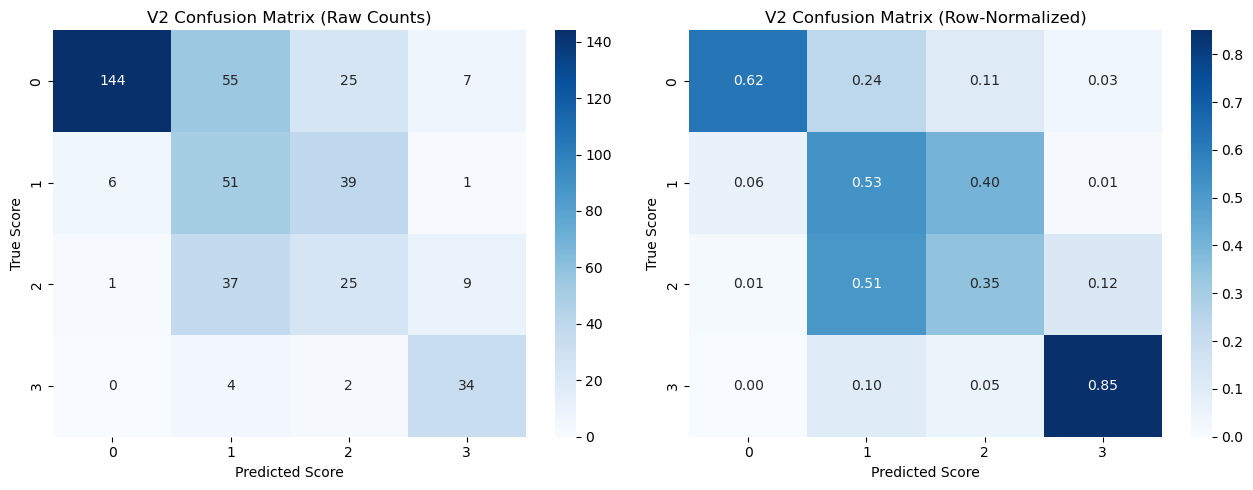


V2 Per-class recall (row-normalized diagonal):
  Score 0: 0.62  (144/231)
  Score 1: 0.53  (51/97)
  Score 2: 0.35  (25/72)
  Score 3: 0.85  (34/40)


In [29]:
# Confusion matrix — V2
cm_v2 = confusion_matrix(y_true_v2, y_pred_v2, labels=[0, 1, 2, 3])
cm_v2_norm = cm_v2.astype(float) / cm_v2.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3], ax=axes[0])
axes[0].set_xlabel('Predicted Score')
axes[0].set_ylabel('True Score')
axes[0].set_title('V2 Confusion Matrix (Raw Counts)')

sns.heatmap(cm_v2_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3], ax=axes[1])
axes[1].set_xlabel('Predicted Score')
axes[1].set_ylabel('True Score')
axes[1].set_title('V2 Confusion Matrix (Row-Normalized)')

plt.tight_layout()
plt.show()

print("\nV2 Per-class recall (row-normalized diagonal):")
for i in range(4):
    if cm_v2.sum(axis=1)[i] > 0:
        print(f"  Score {i}: {cm_v2_norm[i,i]:.2f}  ({cm_v2[i,i]}/{cm_v2.sum(axis=1)[i]})")

### V2 Confusion Matrix Interpretation

*Fill in after running evaluation:*
- How well does the V2 model distinguish score 0 (consolidation) from score 1 (minimal progress)?
- Does it capture the rare score 3 (breakthrough) at the right transitions?
- How does V2 compare to V1 on per-class recall?

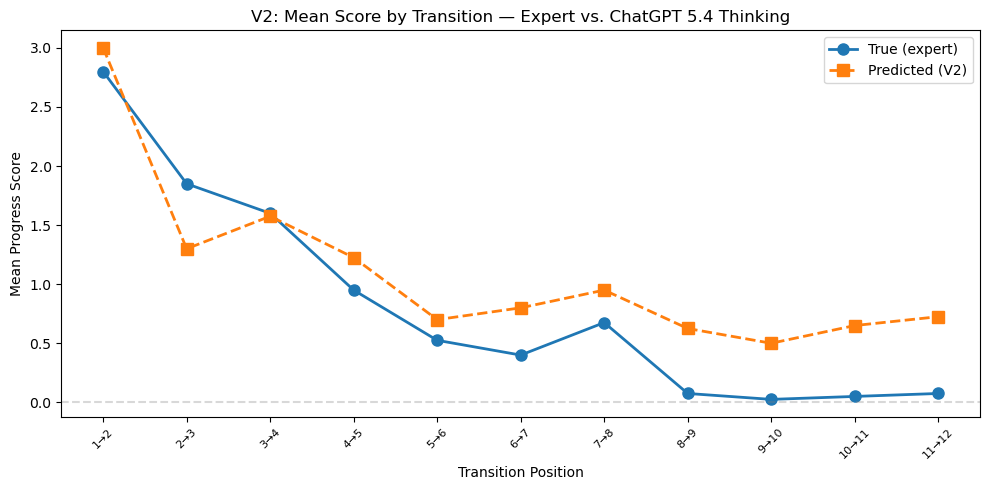

In [30]:
# Per-transition position analysis — V2: mean predicted vs mean true
true_arr_v2 = np.array(y_true_v2).reshape(-1, 11)
pred_arr_v2 = np.array(y_pred_v2).reshape(-1, 11)

fig, ax = plt.subplots(figsize=(10, 5))
positions = range(1, 12)
ax.plot(positions, true_arr_v2.mean(axis=0), 'o-', label='True (expert)', linewidth=2, markersize=8)
ax.plot(positions, pred_arr_v2.mean(axis=0), 's--', label='Predicted (V2)', linewidth=2, markersize=8)
ax.set_xlabel('Transition Position')
ax.set_ylabel('Mean Progress Score')
ax.set_title('V2: Mean Score by Transition — Expert vs. ChatGPT 5.4 Thinking')
ax.set_xticks(range(1, 12))
ax.set_xticklabels([f'{i}→{i+1}' for i in range(1, 12)], rotation=45, fontsize=8)
ax.legend()
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Q1(b): Scoring 80 Unlabeled Clients

Using the V2 (final) prompt validated in Q1(a), score all 80 unlabeled clients and save predictions.

### V2 Prompt (Final) — Unlabeled Data

**Instructions:** Upload `data/unlabeled_notes.json` to ChatGPT 5.4 Thinking, then copy-paste the prompt below.

```
You are a senior speech-language pathologist (SLP) with 15+ years of experience at a pediatric therapy centre. You are replicating the clinical judgment of David Patel, a senior SLP who evaluates children's therapy progress by reading session notes in sequence and assessing how much progress occurred from one session to the next.

## Background

Westfield Children's Centre runs a standardized 12-session speech therapy pathway for young children, organized into two 6-session blocks (Block 1: Sessions 1-6, Block 2: Sessions 7-12). Clinicians write detailed notes after each session documenting the child's performance, goals targeted, level of support needed, and parent/caregiver observations.

Patel's approach is to read the full sequence of notes for a client and compare each note with the one immediately before it. His judgment is grounded in the clinical progress framework below.

## Clinical Progress Framework (Exhibit A)

Clinicians document both the current goal level and the level of independence within that goal at each session. Progress is observed along two dimensions:

Goal Hierarchy (simple to complex speech targets):
  1. Sound production (individual sounds in isolation)
  2. Syllable production (CV, CVC syllable shapes)
  3. Single word production (target sounds in real words)
  4. Carrier phrase production (target words in short fixed phrases)
  5. Sentence production (target words in novel sentences)
  6. Spontaneous speech / conversation (natural connected speech)

Independence Levels (high support to low support):
  1. By imitation (child copies the clinician's model)
  2. With cueing (child produces with verbal, visual, or tactile prompts)
  3. Spontaneously / on their own (child produces without any support)

Progress = movement UP the goal hierarchy, OR reduced reliance on prompting/cueing within the current goal, OR more consistent spontaneous performance. Read across a sequence of sessions, these dimensions reveal the overall trajectory of a child's course of care.

## Your Task

I have uploaded a JSON file (unlabeled_notes.json) containing 80 pediatric speech therapy clients. Each client has 12 consecutive session notes. For each client, evaluate the progress made between each consecutive pair of sessions (11 transitions total: session 1->2, 2->3, ..., 11->12) and assign a progress score from 0 to 3.

## Rating Scale

Score 0 — Maintenance / No Notable Change
The child is functioning at essentially the same level as the previous session. Accuracy, cueing needs, and goal level remain similar. Skills may be practiced or reinforced, but no new ground is broken.
Typical note language: "about the same as last week", "consistent with previous session", "cueing needs similar to last session", "no notable change in independence", "performance was similar", parent reports "about the same" or "speech continues to be similar".
Key rule: Good performance at the same level as last session = Score 0, NOT Score 1.

Score 1 — Small but Clear Improvement
Modest progress within the same general level. Slightly better consistency, marginally less cueing, or improved carryover — without a major increase in independence or a jump up the goal hierarchy.
Typical note language: "emerging progress", "variable accuracy but some improvement", "some correct attempts", "still required intensive cueing but slightly improved", parent reports "a little bit clearer".
Examples: slight accuracy increase on existing targets (e.g., 60% to 70% on the same task), marginally less cueing needed but still at the same broad support level, beginning awareness of a new target without consistent success, minor expansion within the same complexity level.
Key rule: A slight accuracy increase on the same task without a goal-level change = Score 1, NOT Score 2.

Score 2 — Meaningful Clinical Progress
An obvious step forward that matters clinically. Moving from inconsistent to fairly consistent performance, clearly requiring less support, or showing broader generalization across activities.
Typical note language: "noticeably better", "increased consistency", "fewer substitutions compared to last session", "accuracy in imitation improved", moved to a new target or level, parent reports "clearer words" or family members understand more.
Examples: moving up one step in the goal hierarchy (e.g., isolation to syllables, words to phrases), noticeable reduction in cueing level (e.g., maximal to moderate, moderate to minimal), consistent accuracy improvement across multiple targets, meeting a goal and transitioning to the next target.
Key rule: Moving up one step in the goal hierarchy OR one step in independence level = Score 2.

Score 3 — Major Gain / Breakthrough (USE SPARINGLY)
A clear breakthrough: a hierarchy jump, major gain in independence, or a new level of spontaneous use. This score should be rare.
Typical note language: "marked improvements across multiple targets", clear hierarchy jump (e.g., isolation to words), major shift from supported to independent production.
Examples: transition from baseline assessment to active treatment with multiple new skills emerging (common for session 1 to 2), moving from highly supported production to emerging independence, jumping multiple complexity levels in one session.
Key rule: Score 3 requires BOTH a clear hierarchy jump AND a major independence gain, OR a transition from baseline assessment to active treatment with multiple new skills. The first session transition (session 1 to 2) often scores 3 because the child moves from initial assessment to active treatment.

## Score Distribution Calibration

In expert-labeled data, the approximate distribution of scores is:
- Score 0: ~50% of all transitions (maintenance/plateau is the most common outcome)
- Score 1: ~22% of transitions (small improvements)
- Score 2: ~16% of transitions (meaningful progress)
- Score 3: ~9% of transitions (rare breakthroughs — mostly early in treatment)

Most children show strong early gains (sessions 1-4) that taper to plateau (sessions 7-12). If your scores are not roughly following this distribution, recalibrate.

## Boundary Decision Rules

Use these rules to resolve ambiguous cases:
- A parent reporting "about the same" is strong evidence for Score 0, even if the clinician notes describe adequate performance.
- Consolidating or reinforcing skills at the same level, even with good accuracy, is Score 0.
- Slight improvement on existing targets without moving to a new goal level = Score 1 (not 2).
- A clear step up in goal hierarchy (e.g., words to phrases) or a clear reduction in cueing level (e.g., maximal to minimal) = Score 2 (not 1).
- Score 3 is reserved for major leaps. If in doubt between 2 and 3, choose 2.

## How to Compare Each Pair of Notes

For each consecutive pair of notes (Session N vs Session N+1), systematically ask:
  (a) Are new or more complex goals being targeted compared to the previous session?
  (b) Has the level of independence changed (less cueing, more spontaneous production)?
  (c) Has accuracy or consistency clearly improved?
  (d) What does the parent/caregiver report say about change since the last session?
Then assign the score based on the overall pattern across these four dimensions.

## Calibration Examples

Example 1 — C_012: [3, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0]
Pattern: Strong breakthrough at session 1->2 (baseline to active treatment with multiple new skills). Meaningful progress continues at session 2->3 (moved up goal hierarchy). Small incremental gains through mid-sessions (slightly better accuracy, marginally less cueing). Full plateau in later sessions (same level, same cueing, maintenance work).

Example 2 — C_017: [3, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0]
Pattern: Strong start at session 1->2 (baseline to treatment). Gradual taper through sessions 2-5 (small improvements within same level). Early plateau from session 5 onward (performance consistent with previous weeks, parent reports "about the same"). Brief uptick at transition 10->11 (slight improvement after long plateau). Returns to plateau at 11->12.

Example 3 — C_068: [3, 1, 3, 1, 1, 1, 0, 0, 0, 0, 0]
Pattern: Strong start at session 1->2 (baseline to treatment). Small gain at session 2->3. Rare second breakthrough at session 3->4 (jumped to a new goal level with major independence gain). Gradual taper through sessions 4-7 (incremental gains). Full plateau from session 7 onward (consolidation at achieved level).

## Output Format

Return ONLY a CSV table with this exact format:

client_id,t1_2,t2_3,t3_4,t4_5,t5_6,t6_7,t7_8,t8_9,t9_10,t10_11,t11_12

Each row: client_id followed by 11 integer scores (each 0, 1, 2, or 3).
Exactly 80 rows (one per client), sorted by client_id.
No explanation, commentary, or markdown formatting — ONLY the CSV header and 80 data rows.
```

In [31]:
# Paste the ChatGPT CSV output (from V2 final prompt) between the triple quotes below
raw_output_unlabeled = """
client_id,t1_2,t2_3,t3_4,t4_5,t5_6,t6_7,t7_8,t8_9,t9_10,t10_11,t11_12
C_001,2,2,2,1,2,2,0,0,0,0,0
C_002,3,2,2,2,2,2,1,1,0,0,0
C_003,2,2,1,1,0,2,1,0,0,0,1
C_004,3,2,2,1,2,0,0,0,1,0,0
C_005,3,1,1,2,2,2,0,0,0,0,0
C_007,2,2,2,0,1,0,0,0,0,0,0
C_008,3,3,2,2,1,2,1,0,0,0,0
C_009,3,2,2,1,2,1,0,1,0,0,0
C_011,2,2,2,1,1,2,1,0,0,0,0
C_013,2,2,1,0,2,1,1,0,0,0,0
C_015,3,2,1,1,0,0,1,0,0,0,0
C_016,3,2,1,1,1,1,0,0,0,0,0
C_018,3,2,2,2,1,1,1,0,0,0,0
C_019,2,2,2,0,0,1,0,0,0,0,0
C_020,2,2,1,2,0,1,0,0,0,0,0
C_021,3,2,2,2,1,1,0,0,0,0,0
C_022,3,2,2,0,2,1,2,0,0,0,0
C_023,3,1,2,1,2,1,1,0,0,0,0
C_025,3,2,1,2,2,0,0,0,0,0,0
C_026,2,2,2,1,1,1,1,0,0,0,0
C_028,2,2,2,1,0,0,0,0,0,0,0
C_030,2,2,1,2,0,0,0,0,0,0,0
C_031,2,2,2,0,2,1,3,0,0,0,0
C_033,2,2,2,0,1,2,0,0,1,0,1
C_037,1,2,1,1,1,0,1,0,0,0,0
C_038,2,1,2,1,1,0,0,0,0,0,0
C_039,3,1,2,2,1,1,1,0,0,0,0
C_040,2,2,1,0,2,1,1,0,0,0,0
C_041,2,2,1,2,0,1,0,0,0,0,0
C_042,3,2,2,0,2,1,0,1,0,1,0
C_043,2,2,2,2,1,2,1,1,0,0,0
C_044,2,2,2,1,1,2,0,0,0,0,0
C_048,2,2,1,2,0,0,0,0,0,0,0
C_049,2,2,1,2,1,1,0,0,0,0,0
C_050,3,2,2,1,2,0,2,0,0,0,1
C_051,3,3,2,1,1,2,1,0,0,0,1
C_052,3,2,2,1,1,1,1,0,0,0,0
C_053,2,2,1,2,0,1,0,0,0,0,0
C_054,3,2,2,1,1,2,1,0,0,1,0
C_055,3,2,2,1,0,2,1,0,0,1,0
C_057,3,2,1,0,1,2,1,0,0,0,0
C_058,2,2,2,2,0,0,0,0,0,0,0
C_059,2,2,2,0,2,0,0,0,0,0,1
C_060,3,2,2,2,0,1,2,0,0,0,0
C_062,3,2,2,0,1,1,2,0,0,0,0
C_065,2,2,1,1,0,2,2,0,0,0,0
C_066,3,2,1,2,1,2,0,0,0,0,1
C_067,2,1,2,2,0,1,3,0,0,0,0
C_069,3,2,0,1,1,0,0,0,0,1,1
C_070,3,2,1,2,0,2,0,0,0,1,0
C_071,2,0,2,1,0,2,1,0,0,0,0
C_074,3,2,1,1,1,0,0,0,0,0,0
C_076,3,3,1,1,1,2,1,0,0,0,0
C_077,3,2,2,0,0,0,0,0,0,0,0
C_078,3,2,2,1,2,1,1,0,0,0,0
C_079,3,2,1,1,0,0,1,0,0,0,1
C_080,3,3,1,2,2,0,2,0,0,1,0
C_081,3,2,2,2,2,1,1,1,0,0,0
C_082,3,2,2,1,2,1,0,0,0,0,0
C_083,2,2,2,0,1,0,0,0,0,0,0
C_084,3,2,1,2,2,1,1,1,0,0,1
C_087,3,2,2,2,0,0,0,0,0,1,2
C_088,3,2,3,2,1,2,0,0,0,0,0
C_094,3,2,2,0,0,1,1,0,0,0,0
C_095,3,2,2,1,1,2,0,0,0,0,0
C_096,3,2,1,2,1,0,1,0,0,0,0
C_097,3,2,2,1,1,0,0,1,0,0,0
C_098,2,2,1,1,1,1,2,0,0,0,0
C_099,3,2,2,2,0,0,0,0,0,0,0
C_100,2,2,2,0,0,2,1,0,0,0,0
C_102,2,1,2,0,0,0,0,0,0,0,0
C_106,2,2,1,0,0,1,0,0,0,0,0
C_107,2,2,2,0,1,0,1,1,0,0,0
C_111,2,2,1,1,2,2,0,0,0,0,0
C_115,2,2,2,2,0,1,1,1,0,0,0
C_118,3,3,2,1,1,0,0,0,1,0,0
C_119,2,2,1,1,0,2,1,0,0,0,0
client_0001,2,3,1,2,0,1,0,0,0,0,0
client_0002,2,1,2,1,0,2,0,0,0,0,0
client_0003,2,2,2,1,0,0,0,0,0,0,0
"""

# --- Robust CSV parser ---
text = raw_output_unlabeled.strip()
if text.startswith("```"):
    lines = text.split("\n")
    lines = [l for l in lines if not l.strip().startswith("```")]
    text = "\n".join(lines).strip()

df_unlabeled_pred = pd.read_csv(io.StringIO(text))

# Validate
assert len(df_unlabeled_pred) == 80, f"Expected 80 rows, got {len(df_unlabeled_pred)}"
score_cols_u = [c for c in df_unlabeled_pred.columns if c.startswith('t')]
assert len(score_cols_u) == 11, f"Expected 11 score columns, got {len(score_cols_u)}"

all_vals_u = df_unlabeled_pred[score_cols_u].values.flatten()
assert all(v in [0, 1, 2, 3] for v in all_vals_u), f"Invalid score values found: {set(all_vals_u) - {0,1,2,3}}"

print(f"Parsed {len(df_unlabeled_pred)} clients, {len(all_vals_u)} total scores")
print(f"\nScore distribution:")
for s in range(4):
    n = (all_vals_u == s).sum()
    print(f"  Score {s}: {n} ({n/len(all_vals_u)*100:.1f}%)")

Parsed 80 clients, 880 total scores

Score distribution:
  Score 0: 407 (46.2%)
  Score 1: 190 (21.6%)
  Score 2: 232 (26.4%)
  Score 3: 51 (5.8%)


In [32]:
# Build and save scored_notes.csv (long format: client_id, session, score)
csv_rows = []
for _, row in df_unlabeled_pred.sort_values('client_id').iterrows():
    for j, col in enumerate(score_cols_u):
        csv_rows.append({'client_id': row['client_id'], 'session': j + 2, 'score': int(row[col])})

scored_df = pd.DataFrame(csv_rows)
scored_df.to_csv('scored_notes.csv', index=False)

print(f"Saved scored_notes.csv: {len(scored_df)} rows")
print(f"Columns: {list(scored_df.columns)}")
print(f"Session range: {scored_df['session'].min()} to {scored_df['session'].max()}")
print(f"\nFirst few rows:")
scored_df.head(15)

Saved scored_notes.csv: 880 rows
Columns: ['client_id', 'session', 'score']
Session range: 2 to 12

First few rows:


,client_id,session,score
0,C_001,2,2
1,C_001,3,2
2,C_001,4,2
3,C_001,5,1
4,C_001,6,2
5,C_001,7,2
6,C_001,8,0
7,C_001,9,0
8,C_001,10,0
9,C_001,11,0


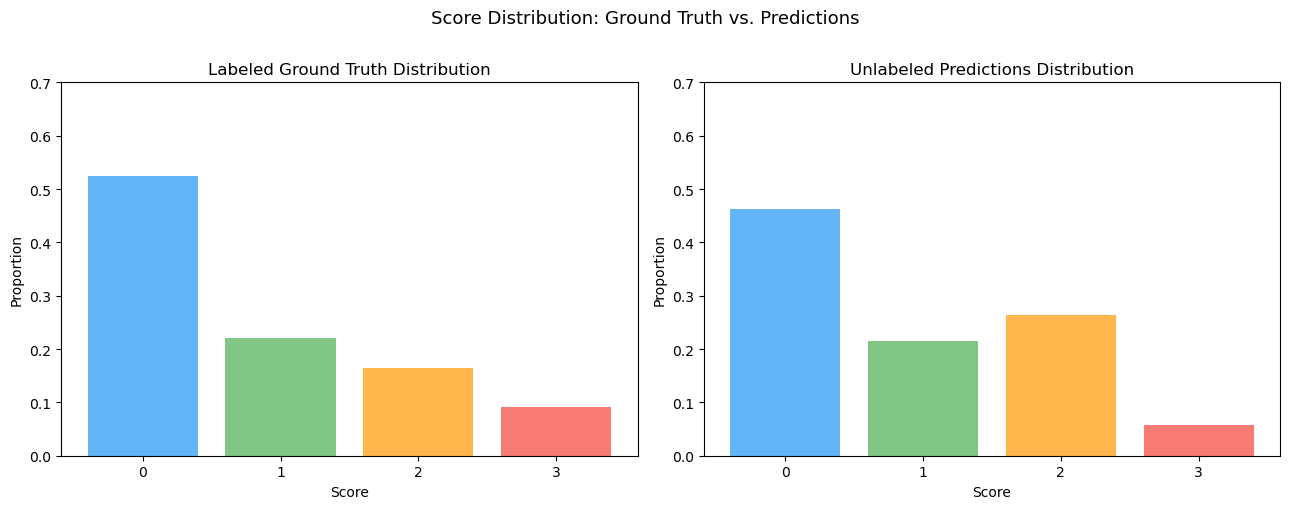

Score       Labeled  Predicted
------------------------------
0             52.5%      46.2%
1             22.0%      21.6%
2             16.4%      26.4%
3              9.1%       5.8%


In [33]:
# Distribution comparison: labeled ground truth vs unlabeled predictions
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Labeled ground truth
labeled_scores = [s for c in labeled_data for s in c['scored_progress']]
labeled_counts = pd.Series(labeled_scores).value_counts().sort_index()
axes[0].bar(labeled_counts.index, labeled_counts.values / len(labeled_scores),
            color=colors, alpha=0.7)
axes[0].set_title('Labeled Ground Truth Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Proportion')
axes[0].set_xticks([0,1,2,3])
axes[0].set_ylim(0, 0.7)

# Unlabeled predictions
pred_scores = scored_df['score'].tolist()
pred_counts = pd.Series(pred_scores).value_counts().sort_index()
axes[1].bar(pred_counts.index, pred_counts.values / len(pred_scores),
            color=colors, alpha=0.7)
axes[1].set_title('Unlabeled Predictions Distribution')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Proportion')
axes[1].set_xticks([0,1,2,3])
axes[1].set_ylim(0, 0.7)

plt.suptitle('Score Distribution: Ground Truth vs. Predictions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Numeric comparison
print(f"{'Score':<8} {'Labeled':>10} {'Predicted':>10}")
print("-" * 30)
for s in range(4):
    l_pct = labeled_counts.get(s, 0) / len(labeled_scores) * 100
    p_pct = pred_counts.get(s, 0) / len(pred_scores) * 100
    print(f"{s:<8} {l_pct:>9.1f}% {p_pct:>9.1f}%")

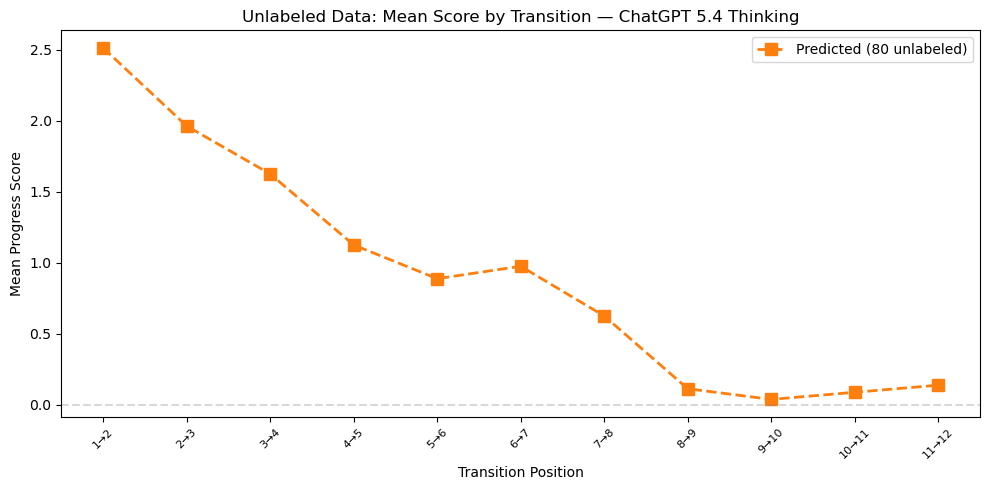

In [34]:
# Mean score by transition position — unlabeled predictions
pred_arr_u = df_unlabeled_pred[score_cols_u].values

fig, ax = plt.subplots(figsize=(10, 5))
positions = range(1, 12)
ax.plot(positions, pred_arr_u.mean(axis=0), 's--', label='Predicted (80 unlabeled)', linewidth=2, markersize=8, color='tab:orange')
ax.set_xlabel('Transition Position')
ax.set_ylabel('Mean Progress Score')
ax.set_title('Unlabeled Data: Mean Score by Transition — ChatGPT 5.4 Thinking')
ax.set_xticks(range(1, 12))
ax.set_xticklabels([f'{i}→{i+1}' for i in range(1, 12)], rotation=45, fontsize=8)
ax.legend()
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Aspect | Details |
|--------|---------|
| **Model** | ChatGPT 5.4 Thinking |
| **Approach** | Manual chatbot — upload JSON, paste prompt, get CSV |
| **Prompt strategies** | Persona, scale, calibration, framework, few-shot, CSV format |
| **Q1(a) — Labeled evaluation** | V1 + V2 prompts on 40 clients (440 scores) — evaluated against ground truth |
| **Q1(b) — Unlabeled scoring** | V2 final prompt on 80 clients (880 scores) — saved to `scored_notes.csv` |
| **Primary metric** | Quadratic Weighted Kappa (QWK) |

**Strengths:**
- Batch processing: all clients scored in one pass, enabling cross-client calibration
- Reasoning model: extended chain-of-thought for nuanced clinical assessment
- Large context window: can ingest entire JSON files without truncation

**Limitations:**
- Not reproducible without saving the exact conversation
- No temperature control or seed parameter
- Manual workflow requires copy-paste steps